In [1]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset, DataLoader
from mediapipe_handcrop import MediapipeHandCrop2
import os
import cv2
from PIL import Image
import random
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from torchvision import models
from models import *
import torch.nn.functional as F


In [2]:
def setup_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        torch.set_default_dtype(torch.float32)
    else:
        device = torch.device('cpu')
        torch.set_default_dtype(torch.float32)
    return device

device = setup_device()
print(f"Using {device} device")

# Set random seed for reproducibility
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

Using cuda device


## New Test Dataset

In [3]:
transform = transforms.Compose([
    MediapipeHandCrop2(), 
    transforms.Resize((64, 64)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


## Create DataFrame for new test dataset

In [4]:
# Directory containing the dataset
ROOT_DIR = "./asl_test_dataset"
CSV_FILE = "./asl_test_dataset/asl_dataset_csv.csv"

In [5]:
mediapipe_validator = MediapipeHandCrop2(include_characteristic_vectors=True)

data = []

for label in os.listdir(ROOT_DIR):
    label_dir = os.path.join(ROOT_DIR, label)
    
    if os.path.isdir(label_dir):
        for file_name in os.listdir(label_dir):
            file_path = os.path.join(label_dir, file_name)

            # Validate image with Mediapipe and brightness
            try:
                result = mediapipe_validator(file_path)
                if result is None:
                    continue
                cropped_image, characteristic_vectors = result
            
            except Exception as e:
                    print(f"Error processing {file_path}: {e}")
                    continue
                
            data.append({"file_path": file_path, "file_name": file_name, "characteristic_vectors": characteristic_vectors, "label": label})

# Create a DataFrame
test_df = pd.DataFrame(data)

# Save DataFrame to CSV
test_df.to_csv(CSV_FILE, index=False)

print(f"CSV file saved at {CSV_FILE}")


CSV file saved at ./asl_test_dataset/asl_dataset_csv.csv


In [6]:
df = pd.read_csv(CSV_FILE)
print(f"{len(df) = }")
df.head()

len(df) = 328


,file_path,file_name,characteristic_vectors,label
0,./asl_test_dataset\A\a.png,a.png,"[[24.47508587397582, 64.30797771697348], [42.1...",A
1,./asl_test_dataset\A\a1.png,a1.png,"[[24.301576025345746, 64.1974068809958], [43.5...",A
2,./asl_test_dataset\A\a2.png,a2.png,"[[21.05881543062171, 64.72933481177505], [41.6...",A
3,./asl_test_dataset\A\a3.png,a3.png,"[[27.447062282238978, 64.28081499519995], [43....",A
4,./asl_test_dataset\A\a4.png,a4.png,"[[14.633149691990443, 64.15316472734723], [36....",A


In [7]:
import ast

class NewTestDataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.csv_file = csv_file
        self.df = pd.read_csv(self.csv_file)
        self.classes = sorted([class_name for class_name in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, class_name))])

        # Maping class names to numbers 
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.classes) if os.path.isdir(os.path.join(self.root_dir, class_name))}

    def __len__(self):
        # Zsumuj liczbę plików w podkatalogach
        dataset_len = sum(
            len(os.listdir(os.path.join(self.root_dir, class_)))
            for class_ in self.classes
            if os.path.isdir(os.path.join(self.root_dir, class_))
        )
        return dataset_len
    
    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("Index out of bounds")
        
        image_path = self.df.loc[idx, "file_path"]
        label = self.class_to_idx[self.df.loc[idx, 'label']]
        characteristic_vectors_str = self.df.loc[idx, "characteristic_vectors"]

        # Konwersja wektorów charakterystycznych
        characteristic_vectors = ast.literal_eval(characteristic_vectors_str)  
        characteristic_vectors = np.array(characteristic_vectors, dtype=np.float32)

                                                     
         # Loading image with cv2
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        
        # Converting to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Transform
        if self.transform:
            image = self.transform(Image.fromarray(image))
        
        return image, label, characteristic_vectors
    

In [8]:
# Train dataset and dataloader initialization
new_test_dataset = NewTestDataset(root_dir=ROOT_DIR, 
                        csv_file=CSV_FILE, 
                        transform=transform,
                        )

## Sanity check

Dataset len:
328

Dataset classes:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Random image from dataset:

Image size:
(64, 64, 3)


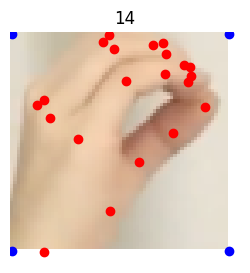

Characteristic vectors: 
[[ 9.512861   64.256676  ]
 [28.900805   52.06327   ]
 [37.61383    37.735294  ]
 [47.46439    29.14084   ]
 [56.811092   21.521883  ]
 [ 9.409246   19.523317  ]
 [26.988792    2.467963  ]
 [41.65216     3.279079  ]
 [50.698235    9.114449  ]
 [ 7.523391   21.088095  ]
 [28.779156    0.37280157]
 [44.388397    2.773257  ]
 [52.446465    9.847091  ]
 [11.268692   24.909727  ]
 [30.067333    4.6112375 ]
 [45.30921     6.0907164 ]
 [52.82457    12.307195  ]
 [19.550522   30.98145   ]
 [33.787476   13.918116  ]
 [45.199703   11.750904  ]
 [52.038944   14.363584  ]]


In [9]:
# Sanity check
print("Dataset len:")
print(len(new_test_dataset))

print("\nDataset classes:")
print(new_test_dataset.classes)

print("\nRandom image from dataset:")
image, label, characteristic_vectors = new_test_dataset[random.randint(0, len(new_test_dataset)-1)]
image = image.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]

print('\nImage size:')
print(image.shape)

# Denormalizing (there was normalization in transform)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image * std + mean
image = image.clip(0, 1)

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.scatter(characteristic_vectors[:, 0], characteristic_vectors[:, 1], c='red')
plt.scatter([0, 0, image.shape[0], image.shape[1]], [0, image.shape[1], image.shape[1], 0], c="blue")  

plt.axis("off")
plt.title(label)
plt.show()

print("Characteristic vectors: ")
print(characteristic_vectors)


Dataset len:
328

Dataset classes:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Random images from dataset:


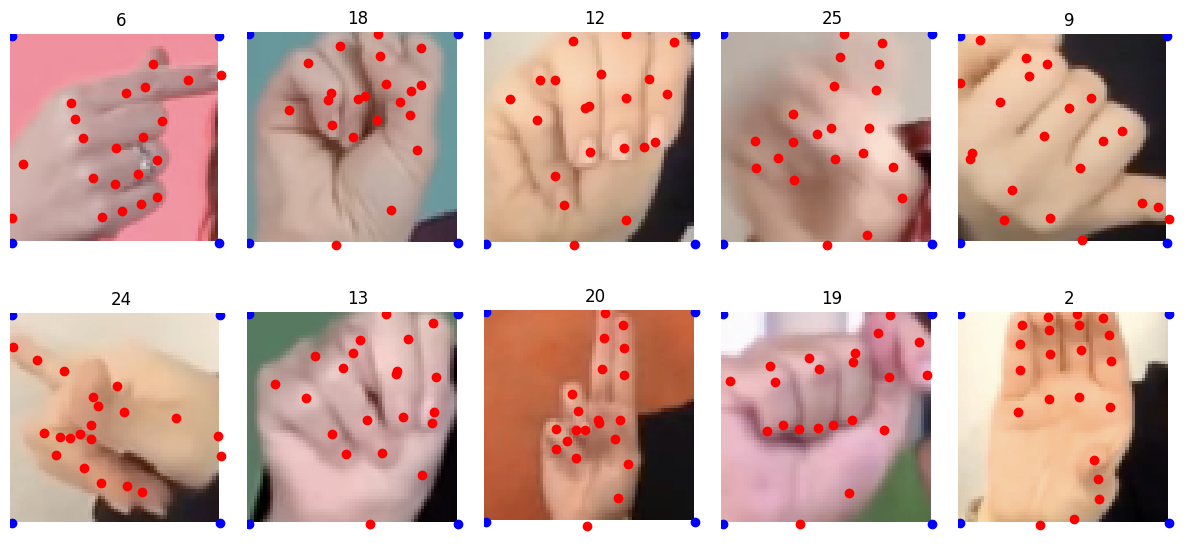

In [10]:
# Sanity check
print("Dataset len:")
print(len(new_test_dataset))

print("\nDataset classes:")
print(new_test_dataset.classes)

print("\nRandom images from dataset:")

plt.figure(figsize=(12,6))
for i in range(10):
    # Fetch image
    image, label, characteristic_vectors = new_test_dataset[random.randint(0, len(new_test_dataset)-1)]
    
    image = image.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]
    
    # Denormalizing (there was normalization in transform)
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    image = image * std + mean
    image = image.clip(0, 1)

    # Ploting
    plt.subplot(2,5,i+1)
    plt.imshow(image)
    plt.scatter(characteristic_vectors[:, 0], characteristic_vectors[:, 1], c='red')
    plt.scatter([0, 0, image.shape[0], image.shape[1]], [0, image.shape[1], image.shape[0], 0], c="blue")  
    plt.axis("off")
    plt.title(label)
    

plt.tight_layout()
plt.show()

# MODEL TESTING

In [11]:
def test_model(device, model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    print(f"Using {model.__class__}")
     
    with torch.inference_mode():
        for i, (images, labels, characteristic_vectors) in enumerate(test_loader):
            images, labels, characteristic_vectors = images.to(device), labels.to(device), characteristic_vectors.to(device)

            if isinstance(model, BaseModel):
                outputs = model(images)  
            elif isinstance(model, MultimodalModel):
                outputs = model(images, characteristic_vectors)
            
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy = 100 * correct / total

    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

    return test_loss, test_accuracy

In [12]:
test_dataloader = DataLoader(new_test_dataset, 
                             batch_size=32, 
                             shuffle=False, 
                             num_workers=0)

In [13]:
def visualize_predictions(model, test_loader, device, criterion, num_images=20):
    model.eval()
    predictions = []
    true_labels = []

    print(f"Using {model.__class__}")
    
    with torch.inference_mode():
        for images, labels, characteristic_vectors in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            characteristic_vectors = characteristic_vectors.to(device)
            
            if isinstance(model, BaseModel):
                outputs = model(images)  
            elif isinstance(model, MultimodalModel):
                outputs = model(images, characteristic_vectors)

            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs, 1)
            
            predictions.extend(predicted.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    plt.figure(figsize=(15, 6))
    num_images = min(num_images, len(predictions))
    indices = random.sample(range(len(predictions)), num_images)
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for i, idx in enumerate(indices):
        image, label, _ = test_loader.dataset[idx]  # Correct unpacking
        image = image.permute(1, 2, 0).numpy()
        
        # Denormalize image
        image = image * std + mean
        image = np.clip(image, 0, 1)
        
        plt.subplot(4, num_images//4, i + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(f'Pred: {predictions[idx]}, True: {label}')
    
    plt.tight_layout()
    plt.show()

In [14]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def visualize_softmax(device, model, test_loader, class_names):
    model.eval()

    print(f"Using {model.__class__}")

    labels_ = []
     
    with torch.inference_mode():
        for images, labels, characteristic_vectors in test_loader:
            images, labels, characteristic_vectors = images.to(device), labels.to(device), characteristic_vectors.to(device)

            if isinstance(model, BaseModel):
                outputs = model(images)  
            elif isinstance(model, MultimodalModel):
                outputs = model(images, characteristic_vectors)
            labels_.append(labels)

    for i in range(5):
        output = outputs[i]
        label - labels_[i]

        # Compute softmax probabilities
        probabilities = F.softmax(output, dim=0) 
        predicted_index = probabilities.argmax(dim=0).item() 
        
        # Format probabilities to avoid scientific notation and create a dict
        formatted_probabilities = {class_names[j]: float(f"{prob:.4f}") for j, prob in enumerate(probabilities.cpu().numpy())}

        # Get the true andpredicted class
        true_class = class_names[label]
        predicted_class = class_names[predicted_index]
        
        # Print results to console
        print(f"True class: {label}")
        print(f"Predicted class: {predicted_class}")
        print(f"Class probabilities: {formatted_probabilities}\n")
        
        # Convert image to numpy for visualization
        image_np = images[i].cpu().permute(1, 2, 0).numpy()  # Change shape from (C, H, W) to (H, W, C)

        plt.figure(figsize=(4, 4))
        image = image_np * std + mean
        image = np.clip(image, 0, 1)

        plt.imshow(image)
        plt.axis('off')
        plt.title(f"True class: {true_class}\nPredicted class: {predicted_class}")
        plt.show() 


# BASE MODEL

In [15]:
num_classes=len(new_test_dataset.classes)
model = BaseModel(num_classes)
model = torch.load(r".\models\base_model\base_model")
model.to(device)

C:\Users\Hyperbook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Hyperbook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Hyperbook\AppData\Local\Temp\ipykernel_9956\2812291018.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), whic

BaseModel(
  (base_model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d

### ACCURACY

In [16]:
criterion = nn.CrossEntropyLoss()
test_model(device, model, test_dataloader, criterion)

Using <class 'models.BaseModel'>
Test Loss: 0.1412, Test Accuracy: 29.27%


(0.1412109085699407, 29.26829268292683)

### PREDICTIONS VISUALIZATION

Using <class 'models.BaseModel'>


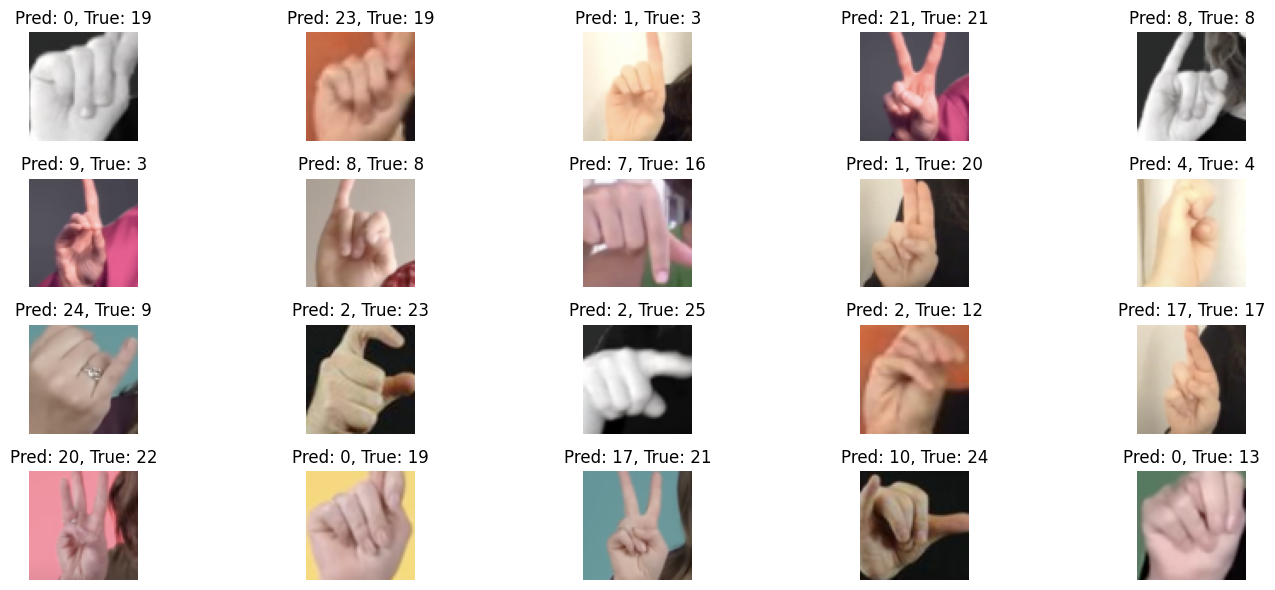

In [17]:
visualize_predictions(model, test_dataloader, device, criterion)

### SOFTMAX VISUALIZATION

Using <class 'models.BaseModel'>
True class: 2
Predicted class: S
Class probabilities: {'A': 0.0021, 'B': 0.0003, 'C': 0.0058, 'D': 0.0008, 'E': 0.0029, 'F': 0.0002, 'G': 0.0606, 'H': 0.0298, 'I': 0.0079, 'J': 0.0027, 'K': 0.0003, 'L': 0.0004, 'M': 0.0014, 'N': 0.0244, 'O': 0.0062, 'P': 0.0008, 'Q': 0.0002, 'R': 0.0003, 'S': 0.5483, 'T': 0.0063, 'U': 0.0002, 'V': 0.0002, 'W': 0.0002, 'X': 0.2952, 'Y': 0.0011, 'Z': 0.0017}



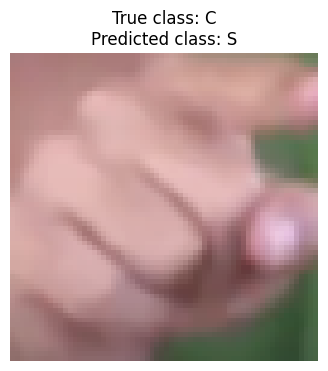

True class: 2
Predicted class: X
Class probabilities: {'A': 0.0031, 'B': 0.0014, 'C': 0.0887, 'D': 0.0002, 'E': 0.0214, 'F': 0.0003, 'G': 0.0084, 'H': 0.144, 'I': 0.0089, 'J': 0.022, 'K': 0.0004, 'L': 0.0013, 'M': 0.022, 'N': 0.174, 'O': 0.0187, 'P': 0.0003, 'Q': 0.0017, 'R': 0.0039, 'S': 0.0568, 'T': 0.1555, 'U': 0.0024, 'V': 0.0004, 'W': 0.0009, 'X': 0.193, 'Y': 0.0685, 'Z': 0.002}



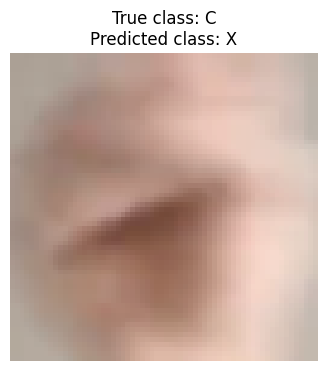

True class: 2
Predicted class: I
Class probabilities: {'A': 0.0012, 'B': 0.0002, 'C': 0.2864, 'D': 0.0021, 'E': 0.0077, 'F': 0.0003, 'G': 0.0005, 'H': 0.002, 'I': 0.5421, 'J': 0.08, 'K': 0.0004, 'L': 0.0012, 'M': 0.0001, 'N': 0.0005, 'O': 0.0178, 'P': 0.0295, 'Q': 0.0046, 'R': 0.0071, 'S': 0.0008, 'T': 0.0002, 'U': 0.0003, 'V': 0.0, 'W': 0.0001, 'X': 0.0058, 'Y': 0.0046, 'Z': 0.0042}



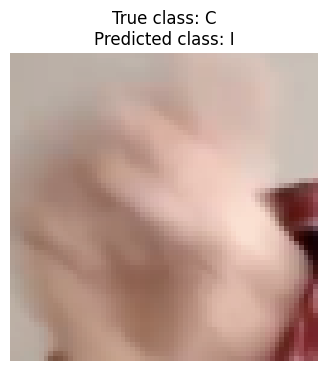

True class: 2
Predicted class: X
Class probabilities: {'A': 0.001, 'B': 0.0021, 'C': 0.001, 'D': 0.0006, 'E': 0.001, 'F': 0.002, 'G': 0.0003, 'H': 0.002, 'I': 0.3367, 'J': 0.0047, 'K': 0.0003, 'L': 0.0002, 'M': 0.0002, 'N': 0.0006, 'O': 0.0004, 'P': 0.0002, 'Q': 0.0001, 'R': 0.0205, 'S': 0.0008, 'T': 0.0015, 'U': 0.0013, 'V': 0.0001, 'W': 0.0002, 'X': 0.6162, 'Y': 0.0046, 'Z': 0.0014}



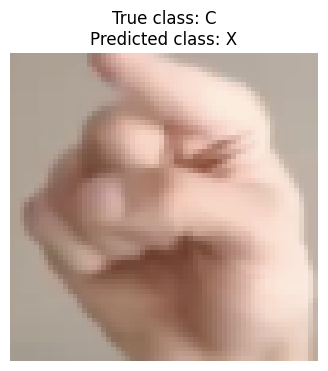

True class: 2
Predicted class: A
Class probabilities: {'A': 0.8139, 'B': 0.0002, 'C': 0.0181, 'D': 0.0004, 'E': 0.0008, 'F': 0.0002, 'G': 0.0008, 'H': 0.0007, 'I': 0.0006, 'J': 0.0009, 'K': 0.0001, 'L': 0.0075, 'M': 0.0003, 'N': 0.0016, 'O': 0.0002, 'P': 0.002, 'Q': 0.0012, 'R': 0.0008, 'S': 0.0205, 'T': 0.046, 'U': 0.0, 'V': 0.0, 'W': 0.0, 'X': 0.0624, 'Y': 0.0047, 'Z': 0.0159}



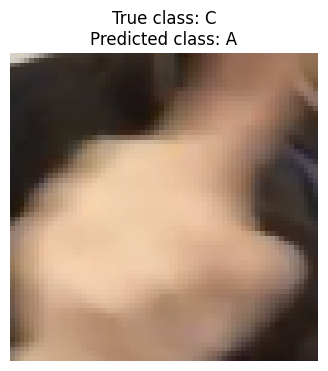

In [18]:
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
visualize_softmax(device, model, test_dataloader, class_names)  

### CONFUSION MATRIX

In [19]:
#TODO confusion matrix for base model

# MULTIMODAL MODEL


In [20]:
num_classes=len(new_test_dataset.classes)
model = MultimodalModel(num_classes, num_landmarks=21)
model = torch.load(r"./models/multimodal_model/multimodal_model")
model.to(device)

C:\Users\Hyperbook\AppData\Local\Temp\ipykernel_9956\2603321594.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(r"./models/multimodal_model/multimodal

AttributeError: 'collections.OrderedDict' object has no attribute 'to'

### TESTING

In [61]:
criterion = nn.CrossEntropyLoss()
test_loss, test_accuracy = test_model(device, model, test_dataloader, criterion)

Using <class 'models.MultimodalModel'>
Test Loss: 0.0734, Test Accuracy: 69.51%


### PREDICTIONS VISUALIZATION

Using <class 'models.MultimodalModel'>


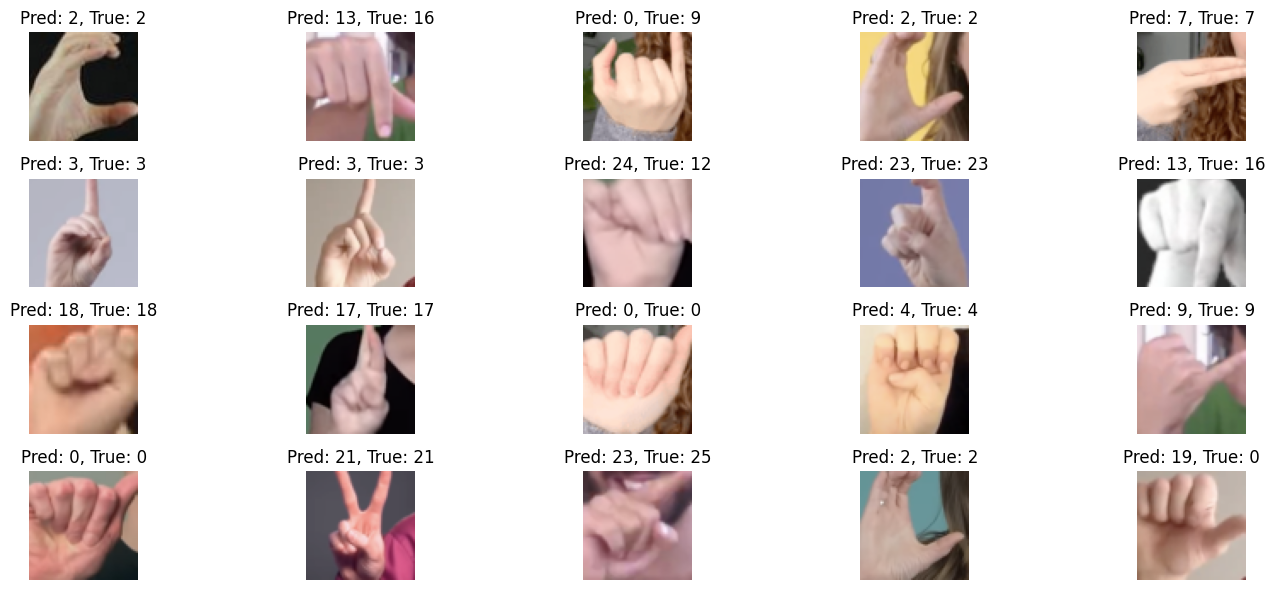

In [ ]:
visualize_predictions(model, test_dataloader, device, criterion)

### SOFTMAX VISUALIZATION

In [71]:
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
visualize_softmax(device, model, test_dataloader, class_names)  

tensor([[-1.3807,  2.1990,  5.8733,  1.6884,  1.2875, -1.9937, -2.2702,  1.6154,
          1.8250,  1.0352, -3.1006, -1.6053,  0.8284,  2.2057,  4.0432,  0.8063,
          2.0790, -2.1406, -1.9598, -1.2790, -1.7705, -2.6401, -2.3713, -0.2187,
          1.3488, -1.8217]], device='cuda:0')
Predicted class: C
Class probabilities: [0.0005, 0.0191, 0.7521, 0.0114, 0.0077, 0.0003, 0.0002, 0.0106, 0.0131, 0.006, 0.0001, 0.0004, 0.0048, 0.0192, 0.1206, 0.0047, 0.0169, 0.0002, 0.0003, 0.0006, 0.0004, 0.0002, 0.0002, 0.0017, 0.0082, 0.0003]


### CONFUSION MATRIX

In [55]:
#TODO confusion matrix for multimodal model